<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/KA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [272]:
import pandas as pd
import numpy as np

In [273]:
train=pd.read_csv('/content/drive/MyDrive/Dataset/mlp ka2/train.csv')
train.head(3)

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0


In [274]:
test=pd.read_csv('/content/drive/MyDrive/Dataset/mlp ka2/test.csv')
test.head(3)

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08


In [275]:
train=train.drop('id',axis=1)
test=test.drop('id',axis=1)

In [276]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       90000 non-null  int64  
 1   last_name         90000 non-null  object 
 2   credit_score      80444 non-null  float64
 3   country           83979 non-null  object 
 4   gender            90000 non-null  object 
 5   age               90000 non-null  float64
 6   tenure            90000 non-null  int64  
 7   acc_balance       82743 non-null  float64
 8   prod_count        85137 non-null  float64
 9   has_card          90000 non-null  float64
 10  is_active         90000 non-null  float64
 11  estimated_salary  90000 non-null  float64
 12  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(3), object(3)
memory usage: 8.9+ MB


In [277]:
train.isna().sum()

,0
customer_id,0
last_name,0
credit_score,9556
country,6021
gender,0
age,0
tenure,0
acc_balance,7257
prod_count,4863
has_card,0


In [278]:
train.isna().mean()*100

,0
customer_id,0.000000
last_name,0.000000
credit_score,10.617778
country,6.690000
gender,0.000000
age,0.000000
tenure,0.000000
acc_balance,8.063333
prod_count,5.403333
has_card,0.000000


checking if customer id is repeated or single customer id for every row.If customer id is unique for row every we can drop this column

In [279]:
train['customer_id'].value_counts(),len(train['customer_id'].unique())

(customer_id
 15682355    72
 15595588    56
 15585835    50
 15648067    50
 15782530    50
             ..
 15571277     1
 15672989     1
 15654875     1
 15593682     1
 15753850     1
 Name: count, Length: 18247, dtype: int64,
 18247)

so out of 90000,18247 customer id is unique and rest is repeated so for now we will not drop this column.


In [280]:
train.describe(include=np.number)

,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [281]:
train.describe(include=object)

,last_name,country,gender
count,90000,83979,90000
unique,2611,3,2
top,Hsia,France,Male
freq,1343,47966,50914


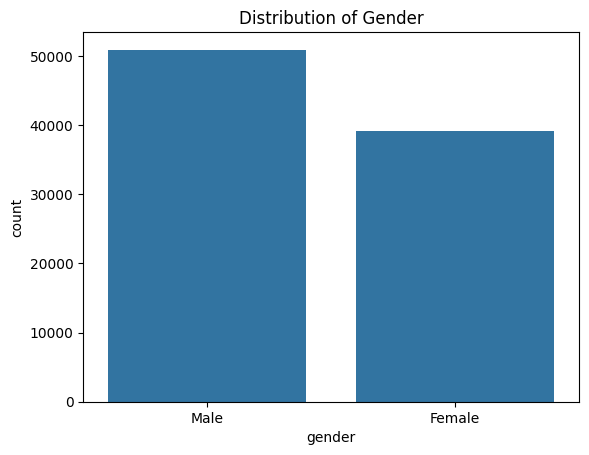

In [282]:
sns.countplot(train,x='gender')
plt.title('Distribution of Gender')
plt.show()

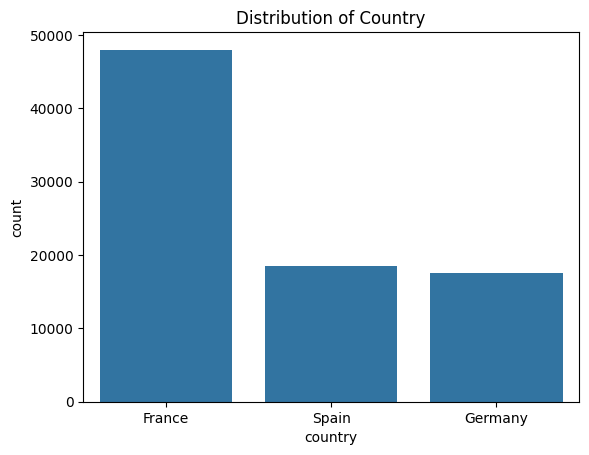

In [283]:
sns.countplot(train,x='country')
plt.title('Distribution of Country')
plt.show()

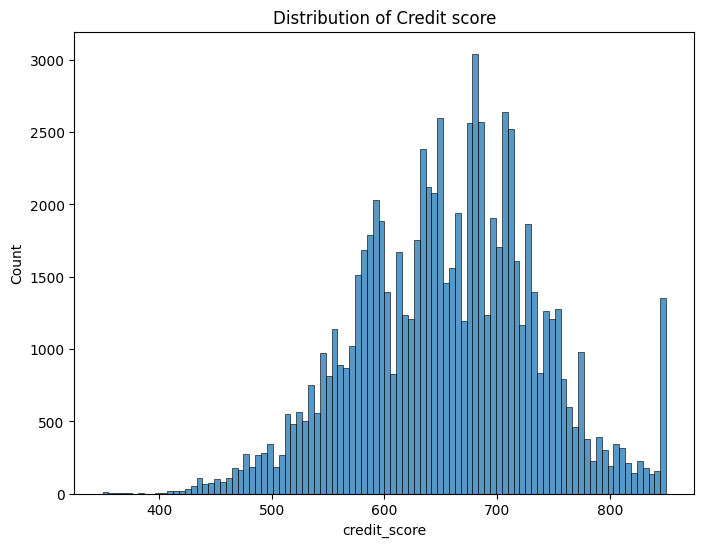

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.histplot(train['credit_score'])
plt.title('Distribution of Credit score')
plt.show()

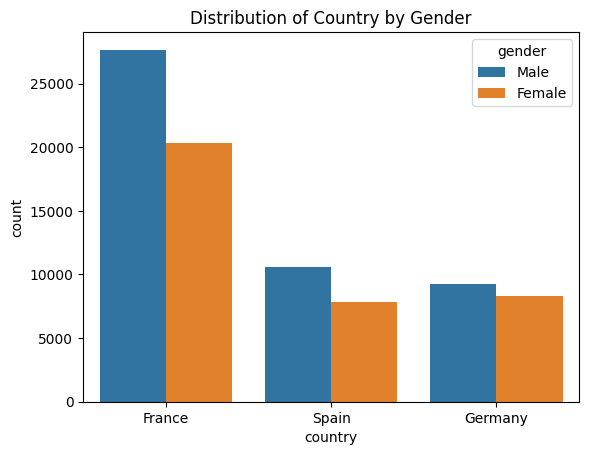

In [285]:
sns.countplot(train,x='country',hue='gender')
plt.title('Distribution of Country by Gender')
plt.show()

In [286]:
country_by_cs=train.groupby('country')['credit_score'].mean().reset_index()
country_by_cs


,country,credit_score
0,France,655.778353
1,Germany,657.435231
2,Spain,657.179819


In [287]:
print('Country having highest credit score',country_by_cs.max())
print("-"*50)
print('Country having lowest credit score',country_by_cs.min())

Country having highest credit score country              Spain
credit_score    657.435231
dtype: object
--------------------------------------------------
Country having lowest credit score country             France
credit_score    655.778353
dtype: object


In [288]:
gender_cs=train.groupby('gender')['credit_score'].mean().reset_index()
gender_cs

,gender,credit_score
0,Female,656.477567
1,Male,656.511989


In [289]:
print('Gender having highest credit score',gender_cs.max())
print("-"*50)
print('Gender having lowest credit score',gender_cs.min())

Gender having highest credit score gender                Male
credit_score    656.511989
dtype: object
--------------------------------------------------
Gender having lowest credit score gender              Female
credit_score    656.477567
dtype: object


In [290]:
gender_es=train.groupby('gender')['estimated_salary'].mean().reset_index()
gender_es

,gender,estimated_salary
0,Female,112939.972596
1,Male,111976.030213


In [291]:
print('Gender having highest estimated salary',gender_es.max())
print("-"*50)
print('Gender having lowest estimated salary',gender_es.min())

Gender having highest estimated salary gender                       Male
estimated_salary    112939.972596
dtype: object
--------------------------------------------------
Gender having lowest estimated salary gender                     Female
estimated_salary    111976.030213
dtype: object


Corelattion of data

In [292]:
cor=train.describe(include=np.number).corr()
cor

,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
customer_id,1.000000,-0.648804,-0.653804,-0.654077,-0.000420,-0.654084,-0.654093,-0.654097,0.307260,-0.654098
credit_score,-0.648804,1.000000,0.999969,0.999965,0.057760,0.999964,0.999964,0.999964,-0.058202,0.999964
age,-0.653804,0.999969,1.000000,1.000000,0.054394,1.000000,1.000000,1.000000,-0.064421,1.000000
tenure,-0.654077,0.999965,1.000000,1.000000,0.053835,1.000000,1.000000,1.000000,-0.064998,1.000000
acc_balance,-0.000420,0.057760,0.054394,0.053835,1.000000,0.053784,0.053759,0.053766,0.776069,0.053764
prod_count,-0.654084,0.999964,1.000000,1.000000,0.053784,1.000000,1.000000,1.000000,-0.065060,1.000000
has_card,-0.654093,0.999964,1.000000,1.000000,0.053759,1.000000,1.000000,1.000000,-0.065081,1.000000
is_active,-0.654097,0.999964,1.000000,1.000000,0.053766,1.000000,1.000000,1.000000,-0.065081,1.000000
estimated_salary,0.307260,-0.058202,-0.064421,-0.064998,0.776069,-0.065060,-0.065081,-0.065081,1.000000,-0.065084
exit_status,-0.654098,0.999964,1.000000,1.000000,0.053764,1.000000,1.000000,1.000000,-0.065084,1.000000


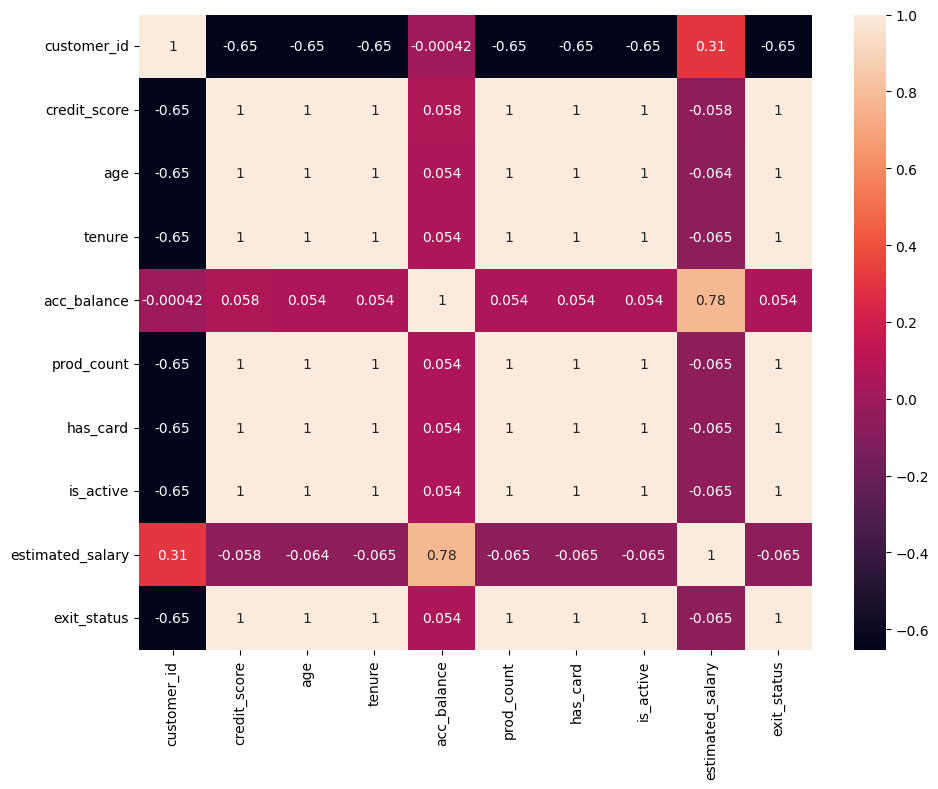

In [293]:
plt.figure(figsize=(10,8))
sns.heatmap(cor,annot=True)
plt.tight_layout()
plt.show()

In [294]:
feature=train.drop('exit_status',axis=1)
labels=train['exit_status'].copy()

In [295]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import RobustScaler
num_pipe=Pipeline([
    ('num_feature',SimpleImputer(strategy='mean')),
    ('num_scaler',RobustScaler())

])
cat_pipe=Pipeline([
    ('num_feature',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])
transforer=ColumnTransformer([
    ('num_pipe',num_pipe,['credit_score','acc_balance','prod_count']),
    ('cat_pipe',cat_pipe,['country'])
],remainder='passthrough',verbose_feature_names_out=False).set_output(transform='pandas')
transforer

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_pipe',
                                 Pipeline(steps=[('num_feature',
                                                  SimpleImputer()),
                                                 ('num_scaler',
                                                  RobustScaler())]),
                                 ['credit_score', 'acc_balance', 'prod_count']),
                                ('cat_pipe',
                                 Pipeline(steps=[('num_feature',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['country'])],
                  verbose_feature_names_out=False)

In [296]:
train_df=transforer.fit_transform(feature)
test_df=transforer.transform(test)

In [297]:
train_df.head(3)

,credit_score,acc_balance,prod_count,country_Germany,country_Spain,country_nan,customer_id,last_name,gender,age,tenure,has_card,is_active,estimated_salary
0,-0.994868,0.900696,-1.0,0.0,0.0,0.0,15788291,Iredale,Male,28.0,1,1.0,1.0,67622.46
1,0.382683,0.596395,0.0,0.0,0.0,0.0,15642816,Hs?,Female,37.0,7,0.0,0.0,182797.86
2,-0.729562,0.089896,0.0,0.0,0.0,1.0,15632272,T'ien,Female,45.0,8,1.0,1.0,170338.35


In [298]:
train_df.isnull().sum().sum(),test_df.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [303]:
for i in train_df[['credit_score','acc_balance','prod_count']]:
    print(np.var(train_df[i]))

0.5958769220021266
0.2666284989900207
0.2840856715905933


In [304]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(train_df,labels,random_state=42,test_size=0.2,shuffle=True)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(72000, 14) (72000,)
(18000, 14) (18000,)
